# Implementation Notebook
### For Lecture 2 - Stanford CS229 - Spring 2026
- Linear Regression
- Batch Gradient Descent


**Imports**

In [ ]:
pip install numpy

In [ ]:
pip install matplotlib

Toy dataset

true $\theta_0 = 3$, true $\theta_1 = 2$

x:  [3.74540119 9.50714306 7.31993942 5.98658484 1.5601864  1.5599452
 0.58083612 8.66176146 6.01115012 7.08072578 0.20584494 9.69909852
 8.32442641 2.12339111 1.81824967 1.8340451  3.04242243 5.24756432
 4.31945019 2.9122914  6.11852895 1.39493861 2.92144649 3.66361843
 4.56069984 7.85175961 1.99673782 5.14234438 5.92414569 0.46450413
 6.07544852 1.70524124 0.65051593 9.48885537 9.65632033 8.08397348
 3.04613769 0.97672114 6.84233027 4.40152494 1.22038235 4.9517691
 0.34388521 9.09320402 2.58779982 6.62522284 3.11711076 5.20068021
 5.46710279 1.84854456]


Text(0, 0.5, 'y')

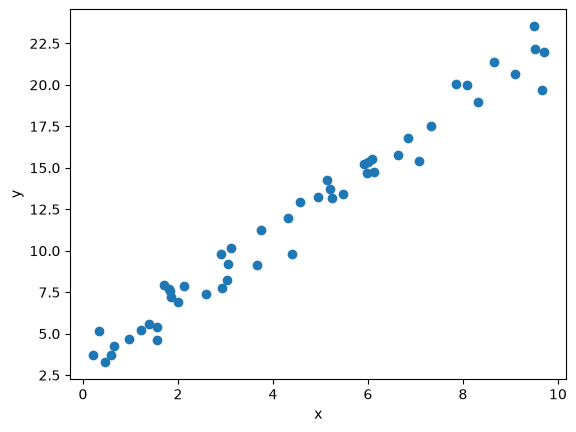

In [24]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

# true relationship y = 3 + 2 * x + noise

n = 50
x = np.random.uniform(0, 10, n)
print("x: ", x)
#print("x shape: ", x.shape)
noise = np.random.normal(0, 1, n)
y = 3 + 2 * x + noise
#print("y: ", y)
#print("y shape: ", y.shape)

plt.plot(x, y, 'o')
plt.xlabel('x')
plt.ylabel('y')

### 1. Closed-form mean/covariance formula for Linear Regression

- Not covered in CS229, as it only works cleanly for the single-feature case
- This is how linear regression is introduced in stats courses
- Listed here just for completeness
- Intuition: $\theta_1$ is (proportional to) covariance of $x,y$ divided by variance of $x$

$$
\theta_1 = \frac{\sum_{i=1}^{n} (x^{(i)} - \bar{x})(y^{(i)} - \bar{y})}{\sum_{i=1}^{n} (x^{(i)} - \bar{x})^2}
$$

$$
\theta_0 = \bar{y} - \theta_1 \bar{x}
$$

**Recall:**
- $\bar{x}$, $\bar{y}$ — just the means (averages) of $x$ and $y$ across all $n$
  training examples: $\bar{x} = \frac{1}{n}\sum_{i=1}^n x^{(i)}$, same for $\bar{y}$
- **Covariance** — measures how two variables move together: positive when they
  tend to increase together, negative when one increases as the other decreases,
  near zero when there's no linear relationship. Sample covariance formula:
  $$
  \text{Cov}(x,y) = \frac{1}{n-1}\sum_{i=1}^{n} (x^{(i)}-\bar{x})(y^{(i)}-\bar{y})
  $$
  The numerator of $\theta_1$, $\sum_i (x^{(i)}-\bar{x})(y^{(i)}-\bar{y})$, is exactly
  this sum before dividing by $(n-1)$ — i.e. proportional to $\text{Cov}(x,y)$
- **Variance** — how spread out a single variable is from its own mean. Sample
  variance formula:
  $$
  \text{Var}(x) = \frac{1}{n-1}\sum_{i=1}^{n} (x^{(i)}-\bar{x})^2
  $$
  Same relationship: the denominator of $\theta_1$ is this sum before dividing by
  $(n-1)$ — proportional to $\text{Var}(x)$
- Since both numerator and denominator are missing the *same* $\frac{1}{n-1}$
  factor, it cancels out in the ratio — which is why $\theta_1$ can be written
  using the raw sums directly, without ever needing to divide by $n-1$
  

**Implementation**

In [28]:
x_bar = x.mean()
y_bar = y.mean()
theta1 = np.sum((x - x_bar) * (y - y_bar)) / np.sum((x - x_bar) ** 2)
print("theta1: ", theta1)

theta0 = y_bar - theta1 * x_bar
print("theta0: ", theta0)

theta1:  1.9776566003853107
theta0:  3.0966892744688828


### 2a. Batch Gradient Descent — loop-based (no matrices/vectors)

- Direct translation of the explicit per-parameter update rule derived by hand:

$$
\theta_j^{(t+1)} = \theta_j^{(t)} - \alpha \sum_{i=1}^{n} \left( h_\theta(x^{(i)}) - y^{(i)} \right) x_j^{(i)}
$$

- Uses plain Python loops over training examples ($i$) and iterations ($t$) —
  no design matrix $X$, just the raw `x`, `y` arrays
- Should converge toward the same $\theta_0, \theta_1$ found by the closed-form
  formula in section 1 — this is the check for correctness
- Recall: $x_0 = 1$ (the intercept trick), $x_1 = x^{(i)}$ (the actual feature)

**Building the design matrix**

Recall that the design matrix $X$ is a matrix such that each row is one training example's feature vector (convention that $x_0 = 1$) so $X$ has $n$ rows.

In [13]:
X = np.column_stack([np.ones(n), x])
assert(X.shape == (n, 2))